<a href="https://colab.research.google.com/github/davihr1/solu-oes-com-integrtais/blob/main/Diferenciabilidade_E_Plano_tangente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4.1 Introdução a Diferenciabilidade de Funçoes de Varias Variaveis



*   Para ilustrar a diferenciabilidade de Funções de Varias Variaveis, calcule o gradiente e a matriz jacobiana de uma função e verifivamos se ela e diferencial em um ponto especifico.

*   Vamos considerar a função f(x, y) = x^2 + x^2 e verificar sua diferenciabilidade em um ponto (1, 2):



In [ ]:
from sympy import symbols, diff, Matrix

#Define as variaveis Simbolicas x e y
x, y = symbols('x y')

#Define a Função
f = x**2 + y**2

#Calcula o gradiente
gradiente = Matrix([diff(f, var) for  var in (x, y)])

#Calcula a matrix jacobiana
jacobiana = gradiente.jacobian([x, y])

#Define o ponto para o qual queremos verificar a diferenciabilidade
ponto = {x: 1, y: 2}

#Verifica se a matriz jacobiana é invertivel no ponto especificado
diferenciavel = jacobiana.subs(ponto).det() != 0

if diferenciavel:
  print("A função f(x, y) é diferenciável no ponto (1, 2).")
else:
  print("A função f(x, y) não é diferenciável no ponto (1, 2).")

A função f(x, y) é diferenciável no ponto (1, 2).


# 4.2 Definição e Propriedades do Plano Tangente



*   Para ilustrar a definição e algumas propriedades do plano tangente a uma superficie em um ponto, podemos criar um codigo que cslcula o plano tangente a uma função de duas variaveis em um ponto especifico e traça o grafico da função junto com o plano tangente.

*   F(x,y) = x^2 + y^2 e calcular o plano tangente em um ponto (1, 2):


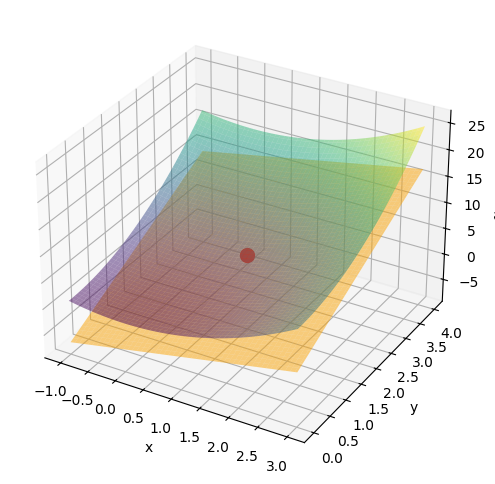

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff

x, y = symbols('x y')

f = x**2 + y**2

ponto = {x: 1, y: 2}

#Calcula as derivadas parciais da função em relação a x e y
df_dx = diff(f, x)
df_dy = diff(f, y)

#Calcula os valores das derivadas no ponto
derivada_x = float(df_dx.subs(ponto))
derivada_y = float(df_dy.subs(ponto))

#Define um ponto no plano tangente
x_pt, y_pt, z_pt = float(ponto[x]), float(ponto[y]), float(f.subs(ponto))

#Calcula o vetor normal ao plano tangente
vetor_normal = np.array([derivada_x, derivada_y, -1])


#Define o grid de valores para x e y
x_vals = np.linspace(x_pt - 2, x_pt + 2, 100)
y_vals = np.linspace(y_pt - 2, y_pt + 2, 100)
X, Y = np.meshgrid(x_vals, y_vals)

#Define o plano tangente
Z_tangente = derivada_x * (X - x_pt) + derivada_y * (Y - y_pt) + z_pt

# Plota o grafico da função e o plano tangente
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')

#Plot da Função
ax.plot_surface(X, Y, X**2 + Y**2, cmap='viridis', alpha=0.5, edgecolor='none')

#Plot do Plano Tangente
ax.plot_surface(X, Y, Z_tangente, alpha=0.5, color='orange', edgecolor='none')

#Plot do ponto no plano tangente
ax.scatter(x_pt, y_pt, z_pt, color='red', s=100, label='Ponto (1, 2)')

#Configuraçoes adicionais
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')

plt.show()

# 4.3 Encontrando a equação do Plano Tangente

* Para encontrar a equação do plano tangente a uma superficie reprersentada por uma função de duas variaveis em um ponto especifico, podemos usar a definição do plano tangente.

* Vamos considerar a função s(x, y) = x^2 + y^2 e encontrar o ponto (1, 2) do plano tangente


In [ ]:
from sympy import symbols, diff

x, y = symbols('x y')

f = x**2 + y**2

ponto = {x: 1, y: 2}

df_dx = diff(f, x)
df_dy = diff(f, y)

derivada_x = float(df_dx.subs(ponto))
derivada_y = float(df_dy.subs(ponto))

x_pt, y_pt, z_pt = ponto[x], ponto[y], f.subs( ponto )

plano_tangente = derivada_x * (x - x_pt) + derivada_y * (y - y_pt) + z_pt

print("A equação do Plano Tangente é:", plano_tangente)

A equação do Plano Tangente é: 2.0*x + 4.0*y - 5.0


# 4.4 Aplicasções do Plano Tngente em Problemas Praticos

As esferas não se interceptam.


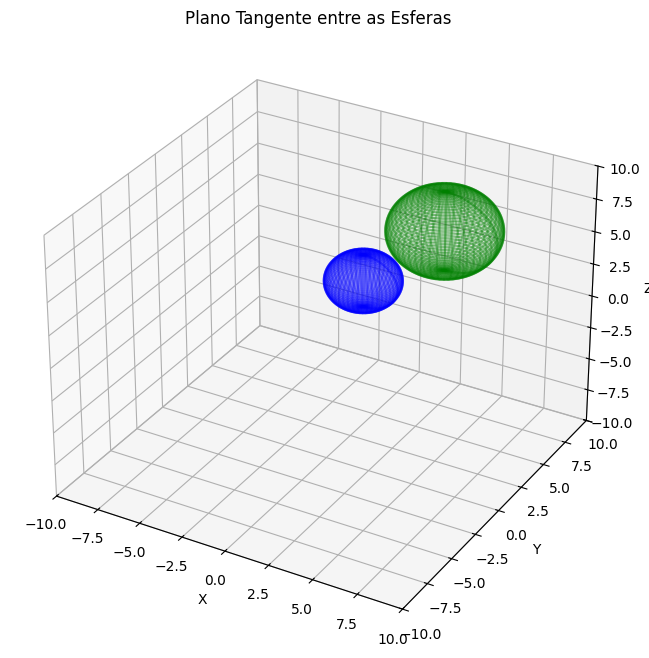

In [ ]:
from matplotlib import figure
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def distancia_segura(x, y, centro_x, centro_y, raio):
  """
  Calcula a distancia segura de um ponto(x, y) ao centro (centro_x, centro_y) respeitando o raio.

  Argumentos:
  x: Coordenada x do ponto.
  y: Coordenada y do ponto.
  centro_x: Coordenada x do centro do circulo.
  centro_y: coordenda y do centro do circulo.
  Raio: Raio da esfera.

  retorna:
    distancia segura do ponto
  """

  distancia_quadrada = (x - centro_x)**2 + (y - centro_y)**2
  if distancia_quadrada <= raio**2:
    return np.sqrt(distancia_quadrada)
  else:
    return 0 #O valor padrão para distancia fora do alcance da esfera

def plano_tangente_esfera(centro1, raio1, centro2, raio2):
  """
  Calcula a equação do plano tangente comum entre duas esferas.

   Argumentos:
   centro1: Tupla representando as coordenadas do centro da primeira esfera (x1, y1, z1).
   raio1: Raio da primeira esfera.
   centro2: Tupla representando as coordenadas do centro da segunda esfera (x2, y2, z2).
   raio2: Raio da segunda esfera.

   Retorna:
   Equação do plano tangente comum uma expressão simbolica ou 'sem plano comum' se as esferas não se interceptam.
  """

  x, y, z = sp.symbols('x y z')

  #Vetor entre os centros das esferas
  v = sp.Matrix(centro2) - sp.Matrix(centro1)

  #Distancia entre os centros das esferas
  d = v.norm()

  #Verificar se a esfera se interceptam (d <= raio1 + raio2)
  if d <= raio1 + raio2:
    #Vetor unitario na direção da linha entre os centros
    n = v / d

    #Coordenadas do ponto de contato
    ponto_contato = sp.Matrix(centro1) + raio1 * n

    #Coeficientes da equação do plano
    A, B, C = n

    #Termo constante da equação do plano
    D = -(A * ponto_contato[0] + B * ponto_contato[1] + C * ponto_contato[2])

    #Equação do plano tangente
    equacao_plano = A * x + B * y + C * z + D
    return equacao_plano

  else:
    return "Sem Plano Comum"

#Define os parametros das esferas
centro1= (1, 2, 3)
raio1= 2
centro2 = (4, 5, 6)
raio2 = 3

#Calcula a equação do plano tangente comum (se exixtir)
equacao_plano = plano_tangente_esfera(centro1, raio1, centro2, raio2)

#Verificar se a esfera se interceptam
if equacao_plano != 'Sem Plano Comum':
    print(f"A equação do plano tangente comum é: {equacao_plano}")
else:
    print("As esferas não se interceptam.")

#Criar uma figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Define os Limites dos eixos para garantir uma boa visualização
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)


#Desenha as esferas
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

#Esfera 1
x_esfera1 = centro1[0] + raio1 * np.outer(np.cos(u), np.sin(v))
y_esfera1 = centro1[1] + raio1 * np.outer(np.sin(u), np.sin(v))
z_esfera1 = centro1[2] + raio1 * np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(x_esfera1, y_esfera1, z_esfera1, color='blue', alpha=0.3)

#Esfera 2
x_esfera2 = centro2[0] + raio2 * np.outer(np.cos(u), np.sin(v))
y_esfera2 = centro2[1] + raio2 * np.outer(np.sin(u), np.sin(v))
z_esfera2 = centro2[2] + raio2 * np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(x_esfera2, y_esfera2, z_esfera2, color='green', alpha=0.3)

#Adicionar Rotulos aos Eixos
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('Plano Tangente entre as Esferas')
plt.show()